In [1]:
import pandas as pd
import random
import os
from DataGenSrc.CANDataGenCountFreq import CANDataInjectionCountFreq
from DataGenSrc.CANFDDataGenCountFreq import CANFDDataInjectionCountFreq

In [2]:
def fuzz_can_id(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replaces the 'CAN_ID' in a DataFrame with random hexadecimal values.

    Args:
        df: The input DataFrame containing CAN bus data with a 'CAN_ID' column.

    Returns:
        A new DataFrame with the 'CAN_ID' column fuzzed.
    """
    # Create a copy to avoid modifying the original DataFrame
    df_fuzzed = df.copy()

    # The user specified a range of 0 to 1000 Hex, which is 0 to 4096 in decimal.
    # We will generate integers from 0 to 4095.
    max_val = 0x1000

    # Apply a lambda function to replace each CAN_ID
    # '{:04X}' formats the integer as a 4-digit uppercase hexadecimal string
    df_fuzzed['CAN_ID'] = df_fuzzed['CAN_ID'].apply(lambda x: f'{random.randrange(max_val):04X}')
    
    return df_fuzzed

In [4]:
path = "/home/lisa/Arupreza/UIDS-II/Normal_Dataset/"

Kia_AF = pd.read_csv(path + "Kia_AF.csv")
Tesla_AF = pd.read_csv(path + "Tesla_AF.csv")
Gen_AF = pd.read_csv(path + "Gen_AF.csv")
Sil_AF = pd.read_csv(path + "Sil_AF.csv")

/tmp/ipykernel_2648357/1896888317.py:5: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  Gen_AF = pd.read_csv(path + "Gen_AF.csv")


In [5]:
Kia_AF_dos_result = CANDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Kia_AF,
    injection_frequency=(1, 33),  # 5 DoS attacks per 30 messages
    label="Fuzz"
)

Injecting 'Fuzz' messages… 100% complete
Done – injected 18181 Fuzz messages in 18181 groups.


In [ ]:
Tesla_AF_dos_result = CANDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Tesla_AF,
    injection_frequency=(8, 30),  # 5 DoS attacks per 30 messages
    label="Fuzz"
)

Injecting 'DoS' messages… 100% complete
Done – injected 160000 DoS messages in 20000 groups.


In [ ]:
Sil_AF_dos_result = CANDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Sil_AF,
    injection_frequency=(8, 30),  # 5 DoS attacks per 30 messages
    label="Fuzz"
)

Injecting 'DoS' messages… 100% complete
Done – injected 160000 DoS messages in 20000 groups.


In [ ]:
Gen_AF_dos_result = CANFDDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Gen_AF,
    injection_frequency=(8, 30)  # 5 DoS attacks per 30 messages
)

Injecting 'DoS' messages...
Generated 160000 'DoS' messages for injection.


In [ ]:
Kia_AF_dos_result.to_csv(os.path.join(path, 'Kia_Fuzz_H.csv'), index=False)
Tesla_AF_dos_result.to_csv(os.path.join(path, 'Tesla_Fuzz_H.csv'), index=False)
Sil_AF_dos_result.to_csv(os.path.join(path, 'Sil_Fuzz_H.csv'), index=False)
Gen_AF_dos_result.to_csv(os.path.join(path, 'Gen_Fuzz_H.csv'), index=False)

In [19]:
path = "/home/lisa/Arupreza/UIDS-II/Input_data/"

Kia_Fuzz_H = pd.read_csv(path + "Kia_Fuzz_H.csv")
Tesla_Fuzz_H = pd.read_csv(path + "Tesla_Fuzz_H.csv")
Sil_Fuzz_H = pd.read_csv(path + "Sil_Fuzz_H.csv")
Gen_Fuzz_H = pd.read_csv(path + "Gen_Fuzz_H.csv")

Kia_Fuzz_M = pd.read_csv(path + "Kia_Fuzz_M.csv")
Tesla_Fuzz_M = pd.read_csv(path + "Tesla_Fuzz_M.csv")
Sil_Fuzz_M = pd.read_csv(path + "Sil_Fuzz_M.csv")
Gen_Fuzz_M = pd.read_csv(path + "Gen_Fuzz_M.csv")

Kia_Fuzz_L = pd.read_csv(path + "Kia_Fuzz_L.csv")
Tesla_Fuzz_L = pd.read_csv(path + "Tesla_Fuzz_L.csv")
Sil_Fuzz_L = pd.read_csv(path + "Sil_Fuzz_L.csv")
Gen_Fuzz_L = pd.read_csv(path + "Gen_Fuzz_L.csv")

In [20]:
Kia_Fuzz_H

,Time_Offset,CAN_ID,Data_Length,One,Two,Three,Four,Five,Six,Seven,Eight,Label
0,6.000000,0340,8,0F,00,D4,2B,EC,00,58,1A,Normal
1,6.215039,003A,1,C5,23,12,15,00,D2,A7,7E,Fuzz
2,6.300000,0251,8,C5,23,C7,15,00,D2,A7,7E,Normal
3,6.400000,02B0,6,EF,FF,00,07,17,D0,-1,-1,Normal
4,7.600000,058B,8,12,00,00,00,00,00,00,40,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
759995,228124.000000,0368,8,07,00,00,00,07,00,00,60,Normal
759996,228124.200000,0329,8,E3,B0,80,0C,11,34,16,10,Normal
759997,228124.316550,05D2,3,C5,23,B7,63,36,D2,A7,7E,Fuzz
759998,228124.500000,0436,4,00,00,00,08,-1,-1,-1,-1,Normal


In [9]:
Kia_AF_dos_result['Label'].value_counts()

Label
Normal    600000
Fuzz       18181
Name: count, dtype: int64

In [19]:
Kia = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Kia_AF,
    injection_df=Kia_AF_Inj,  # This is required for Replay
    injection_frequency=(8, 30),  # 5 replay attacks per 30 messages
    label="Fuzz"
)

Sequential injection… 100% complete
Done – injected 160000 sequential messages in 20000 groups.


In [20]:
Tesla = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Tesla_AF,
    injection_df=Kia_AF_Inj,  # This is required for Replay
    injection_frequency=(8, 30),  # 5 replay attacks per 30 messages
    label="Fuzz"
)

Sequential injection… 100% complete
Done – injected 160000 sequential messages in 20000 groups.


In [21]:
Sil = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Sil_AF,
    injection_df=Kia_AF_Inj,  # This is required for Replay
    injection_frequency=(8, 30),  # 5 replay attacks per 30 messages
    label="Fuzz"
)

Sequential injection… 100% complete
Done – injected 160000 sequential messages in 20000 groups.


In [22]:
Gen = CANFDDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Gen_AF,
    injection_df=Kia_AF_Inj,  # For replay, you need a source DataFrame
    injection_frequency=(8, 30)  # 6 Replay attacks per 30 messages
)

Injecting 'Replay' messages sequentially...
Generated 160000 'Replay' messages for injection.


In [23]:
Kia.to_csv(os.path.join(path, 'Kia_Fuzz_H.csv'), index=False)
Tesla.to_csv(os.path.join(path, 'Tesla_Fuzz_H.csv'), index=False)
Sil.to_csv(os.path.join(path, 'Sil_Fuzz_H.csv'), index=False)
Gen.to_csv(os.path.join(path, 'Gen_Fuzz_H.csv'), index=False)

In [1]:
import pandas as pd
import numpy as np
import os
from AnalysisSrc.assets import PlotCANIDFrequency, LoadPreprocessData, LoadAllDatasets, NormalizePlotComparison
from DataGenSrc.CANFuzzCorrected import CANDataInjectionCountFreq
from DataGenSrc.CANFDFuzzCorrected import CANFDDataInjectionCountFreq
import matplotlib.pyplot as plt

path = "/home/lisa/Arupreza/UIDS-II/Input_data/"

In [2]:
Kia_AF = LoadPreprocessData("Kia_AF.csv")
Tesla_AF = LoadPreprocessData("Tesla_AF.csv")
Sil_AF = LoadPreprocessData("Sil_AF.csv")
Gen_AF = LoadPreprocessData("Gen_AF.csv")

/home/lisa/Arupreza/UIDS-II/AnalysisSrc/assets.py:37: DtypeWarning: Columns (22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path + df)


In [13]:
# Inject a targeted Fuzz attack
Kia = CANFDDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Kia_AF,
    injection_frequency=(2, 30)  # 5 Fuzz attacks per 20 messages
)

Identified 79 unique CAN IDs to target for Fuzz attack.
Injecting 'Fuzz' messages...
Generated 39994 'Fuzz' messages for injection.


In [14]:
# Inject a targeted Fuzz attack
Tesla = CANFDDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Tesla_AF,
    injection_frequency=(2, 30)  # 5 Fuzz attacks per 20 messages
)

Identified 69 unique CAN IDs to target for Fuzz attack.
Injecting 'Fuzz' messages...
Generated 39994 'Fuzz' messages for injection.


In [15]:
# Inject a targeted Fuzz attack
Sil = CANFDDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Sil_AF,
    injection_frequency=(2, 30)  # 5 Fuzz attacks per 20 messages
)

Identified 98 unique CAN IDs to target for Fuzz attack.
Injecting 'Fuzz' messages...
Generated 39992 'Fuzz' messages for injection.


In [16]:
# Inject a targeted Fuzz attack
Gen = CANFDDataInjectionCountFreq(
    type_of_attack="Fuzz",
    orig_df=Gen_AF,
    injection_frequency=(2, 30)  # 5 Fuzz attacks per 20 messages
)

Identified 58 unique CAN IDs to target for Fuzz attack.
Injecting 'Fuzz' messages...
Generated 39996 'Fuzz' messages for injection.


In [17]:
Kia.to_csv(os.path.join(path, 'Kia_Fuzz_L.csv'), index=False)
Tesla.to_csv(os.path.join(path, 'Tesla_Fuzz_L.csv'), index=False)
Sil.to_csv(os.path.join(path, 'Sil_Fuzz_L.csv'), index=False)
Gen.to_csv(os.path.join(path, 'Gen_Fuzz_L.csv'), index=False)

In [1]:
import pandas as pd
import numpy as np
import os
from AnalysisSrc.assets import PlotCANIDFrequency, LoadPreprocessData, LoadAllDatasets, NormalizePlotComparison
from DataGenSrc.CANFuzzCorrected import CANDataInjectionCountFreq
from DataGenSrc.CANFDFuzzCorrected import CANFDDataInjectionCountFreq
from DataGenSrc.RandomCANFuzzCorrected import CANDataInjectionCountFreq
from DataGenSrc.RandomCANFDFuzzCorrected import CANFDDataInjectionCountFreq
import matplotlib.pyplot as plt

path = "/home/lisa/Arupreza/UIDS-II/Input_data/"

In [2]:
kia = pd.read_csv(path + "Kia_Fuzz_R.csv")
tesla = pd.read_csv(path + "Tesla_Fuzz_R.csv")
sil = pd.read_csv(path + "Sil_Fuzz_R.csv")
gen = pd.read_csv(path + "Gen_Fuzz_R.csv")

kia = kia[['Time_Offset', 'CAN_ID', 'Data_Length', 'One', 'Two', 'Three', 'Four','Five', 'Six', 'Seven', 'Eight', 'Label']]
tesla = tesla[['Time_Offset', 'CAN_ID', 'Data_Length', 'One', 'Two', 'Three', 'Four','Five', 'Six', 'Seven', 'Eight', 'Label']]
sil = sil[['Time_Offset', 'CAN_ID', 'Data_Length', 'One', 'Two', 'Three', 'Four','Five', 'Six', 'Seven', 'Eight', 'Label']]
gen = gen[['Time_Offset', 'CAN_ID', 'Type3', 'Data_Length', 'Data1', 'Data2','Data3', 'Data4', 'Data5', 'Data6', 'Data7', 
        'Data8', 'Data9', 'Data10','Data11', 'Data12', 'Data13', 'Data14', 'Data15', 'Data16', 'Data17','Data18', 'Data19', 
        'Data20', 'Data21', 'Data22', 'Data23', 'Data24','Data25', 'Data26', 'Data27', 'Data28', 'Data29', 'Data30', 'Data31', 'Data32', 'Label']]

/tmp/ipykernel_1871502/3112568259.py:4: DtypeWarning: Columns (22,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  gen = pd.read_csv(path + "Gen_Fuzz_R.csv")


In [ ]:
# Kia_AF = LoadPreprocessData("Kia_AF.csv")
# Tesla_AF = LoadPreprocessData("Tesla_AF.csv")
# Sil_AF = LoadPreprocessData("Sil_AF.csv")
# Gen_AF = LoadPreprocessData("Gen_AF.csv")

/home/lisa/Arupreza/UIDS-II/AnalysisSrc/assets.py:37: DtypeWarning: Columns (22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path + df)


In [3]:
Kia_Fuzz_R = CANDataInjectionCountFreq(
    type_of_attack="DoS",
    orig_df=kia,
    group_size=30  # You only need to specify the group size now
)

Injecting 'DoS' messages...
Generated 103643 'DoS' messages for injection.


In [4]:
Tesla_Fuzz_R = CANDataInjectionCountFreq(
    type_of_attack="DoS",
    orig_df=tesla,
    group_size=30  # You only need to specify the group size now
)

Injecting 'DoS' messages...
Generated 103371 'DoS' messages for injection.


In [5]:
Sil_Fuzz_R = CANDataInjectionCountFreq(
    type_of_attack="DoS",
    orig_df=sil,
    group_size=30  # You only need to specify the group size now
)

Injecting 'DoS' messages...
Generated 103359 'DoS' messages for injection.


In [7]:
# --- Demonstrate Fuzz Attack Injection ---
Gen_Fuzz_R = CANFDDataInjectionCountFreq(
    type_of_attack="DoS",
    orig_df=gen
)

Injecting 'DoS' messages with frequency: 7 attacks per 30 messages.


In [10]:
Gen_Fuzz_R.columns

Index(['Time_Offset', 'CAN_ID', 'Type3', 'Data_Length', 'Data1', 'Data2',
       'Data3', 'Data4', 'Data5', 'Data6', 'Data7', 'Data8', 'Data9', 'Data10',
       'Data11', 'Data12', 'Data13', 'Data14', 'Data15', 'Data16', 'Data17',
       'Data18', 'Data19', 'Data20', 'Data21', 'Data22', 'Data23', 'Data24',
       'Data25', 'Data26', 'Data27', 'Data28', 'Data29', 'Data30', 'Data31',
       'Data32', 'Label', 'Data33', 'Data34', 'Data35', 'Data36', 'Data37',
       'Data38', 'Data39', 'Data40', 'Data41', 'Data42', 'Data43', 'Data44',
       'Data45', 'Data46', 'Data47', 'Data48', 'Data49', 'Data50', 'Data51',
       'Data52', 'Data53', 'Data54', 'Data55', 'Data56', 'Data57', 'Data58',
       'Data59', 'Data60', 'Data61', 'Data62', 'Data63', 'Data64', 'Time_Gap'],
      dtype='object')

In [4]:
Kia_Fuzz_R

,Time_Offset,CAN_ID,Data_Length,One,Two,Three,Four,Five,Six,Seven,...,Label,Data1,Data2,Data3,Data4,Data5,Data6,Data7,Data8,Time_Gap
0,16.0,0340,8,0F,00,D5,2B,FC,00,2A,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,17.3,0251,8,DC,23,C8,12,00,E4,37,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.3
2,17.5,02B0,6,EF,FF,00,07,E8,14,-1,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2
3,17.9,0153,8,20,80,10,FF,00,FF,80,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4
4,18.0,0164,4,00,08,02,91,-1,-1,-1,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793663,228123.8,0260,8,03,31,2A,30,0D,D1,A7,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2
793664,228124.0,0368,8,07,00,00,00,07,00,00,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2
793665,228124.2,0329,8,E3,B0,80,0C,11,34,16,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2
793666,228124.5,0436,4,00,00,00,08,-1,-1,-1,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3


In [47]:
Kia_Replay_R = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=kia,
    injection_df=kia[:300000],
    group_size=30  # You only need to specify the group size now
)

Injecting 'Replay' messages sequentially...
Generated 103036 'Replay' messages for injection.


In [ ]:
Tesla_Replay_R = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=tesla,
    injection_df=tesla[:300000],
    group_size=30  # You only need to specify the group size now
)

Injecting 'Replay' messages sequentially...
Generated 90871 'Replay' messages for injection.


In [ ]:
Sil_Replay_R = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=sil,
    injection_df=sil[:300000],
    group_size=30  # You only need to specify the group size now
)

Injecting 'Replay' messages sequentially...


KeyboardInterrupt: 

In [ ]:
Gen_Replay_R = CANFDDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=gen,
    injection_df=gen[:300000],
    #group_size=30  # You only need to specify the group size now
)

Injecting 'Replay' messages sequentially...
Generated 103439 'Replay' messages for injection.


,Time_Offset,CAN_ID,Data_Length,One,Two,Three,Four,Five,Six,Seven,Eight,Label
0,16.0,0340,8,0F,00,D5,2B,FC,00,2A,1A,Normal
1,17.3,0251,8,DC,23,C8,12,00,E4,37,7F,Normal
2,17.5,02B0,6,EF,FF,00,07,E8,14,-1,-1,Normal
3,17.9,0153,8,20,80,10,FF,00,FF,80,2E,Normal
4,18.0,0164,4,00,08,02,91,-1,-1,-1,-1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
690020,228123.8,0260,8,03,31,2A,30,0D,D1,A7,77,Normal
690021,228124.0,0368,8,07,00,00,00,07,00,00,60,Normal
690022,228124.2,0329,8,E3,B0,80,0C,11,34,16,10,Normal
690023,228124.5,0436,4,00,00,00,08,-1,-1,-1,-1,Normal


In [62]:
Kia_Fuzz_R.to_csv(os.path.join(path, 'Kia_DoS_R.csv'), index=False)
Tesla_Fuzz_R.to_csv(os.path.join(path, 'Tesla_DoS_R.csv'), index=False)
Sil_Fuzz_R.to_csv(os.path.join(path, 'Sil_DoS_R.csv'), index=False)
Gen_Fuzz_R.to_csv(os.path.join(path, 'Gen_DoS_R.csv'), index=False)

In [41]:
Kia_Fuzz_R, Tesla_Fuzz_R, Sil_Fuzz_R, Gen_Fuzz_R = LoadAllDatasets("Kia_Rep_R.csv", "Tesla_Rep_R.csv", "Sil_Rep_R.csv", "Gen_Rep_R.csv")

KeyError: 'CAN_ID'

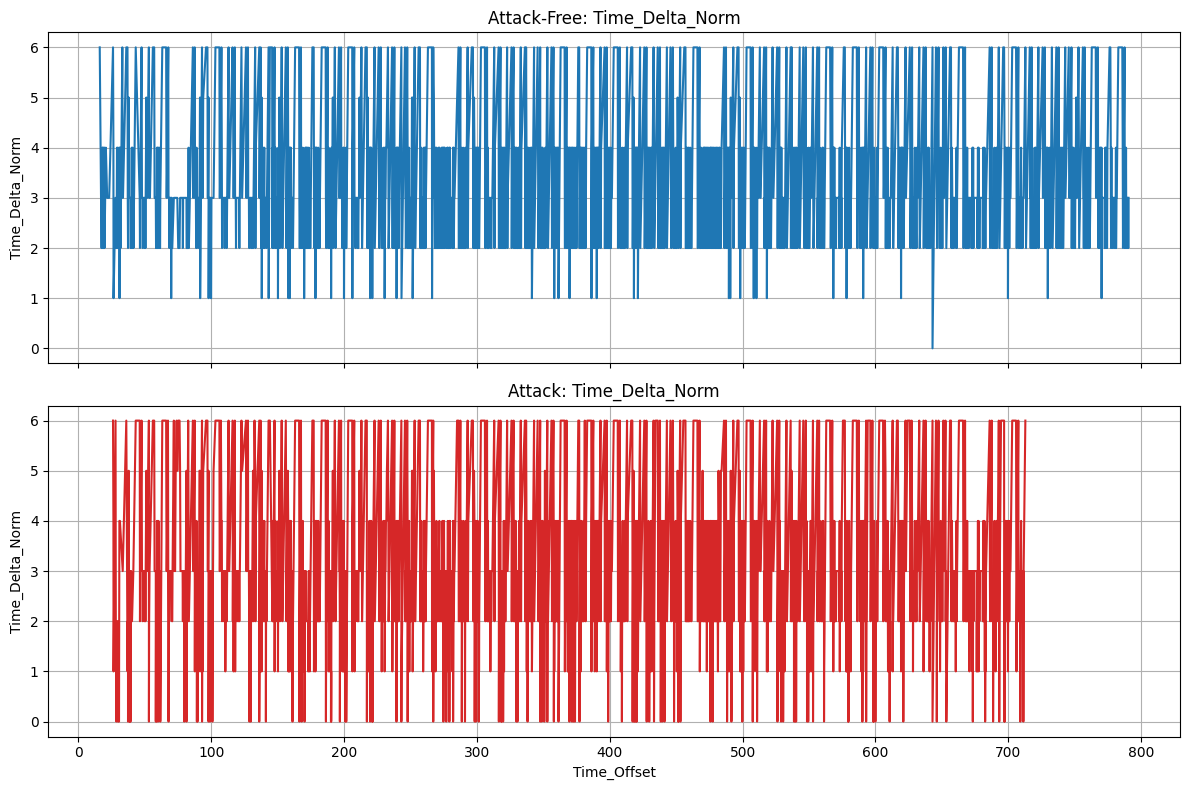

In [ ]:
NormalizePlotComparison(Kia_AF, Kia_Fuzz_R, 'Time_Delta_Norm', 0, 2000)

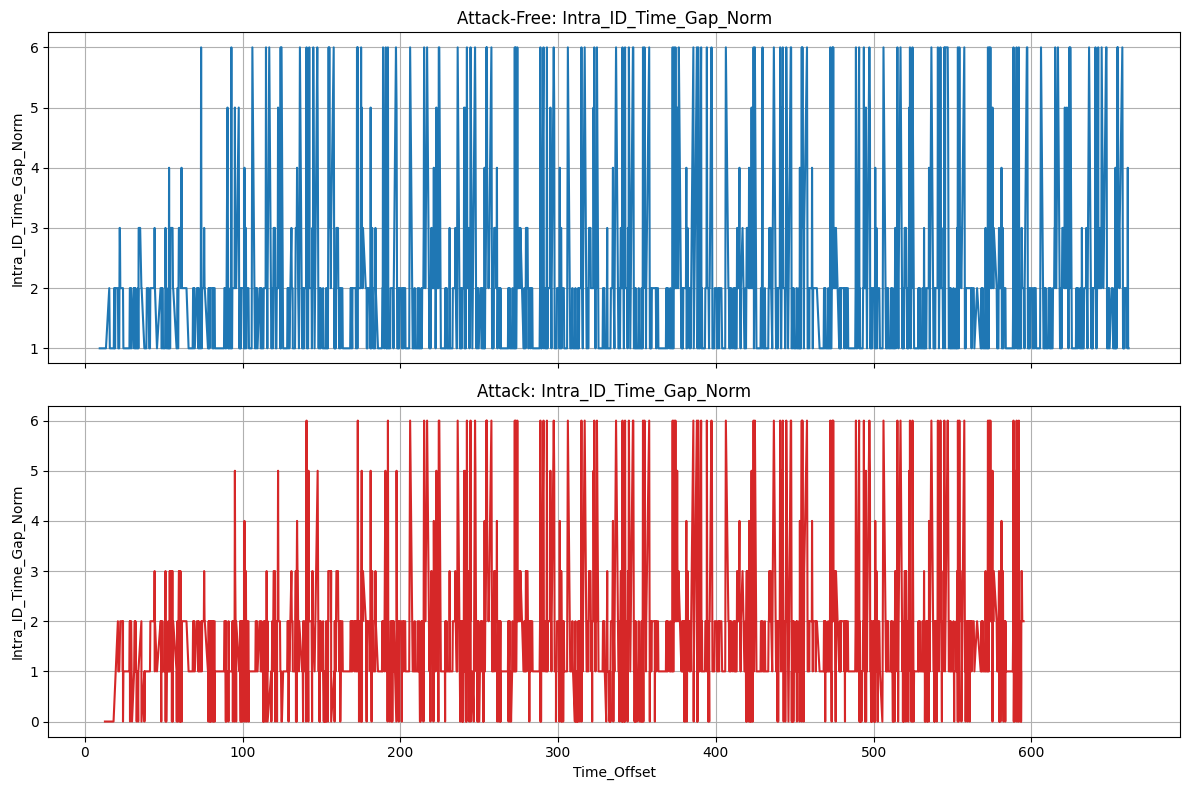

In [ ]:
NormalizePlotComparison(Tesla_AF, Tesla_Fuzz_R, 'Intra_ID_Time_Gap_Norm', 0, 2000)

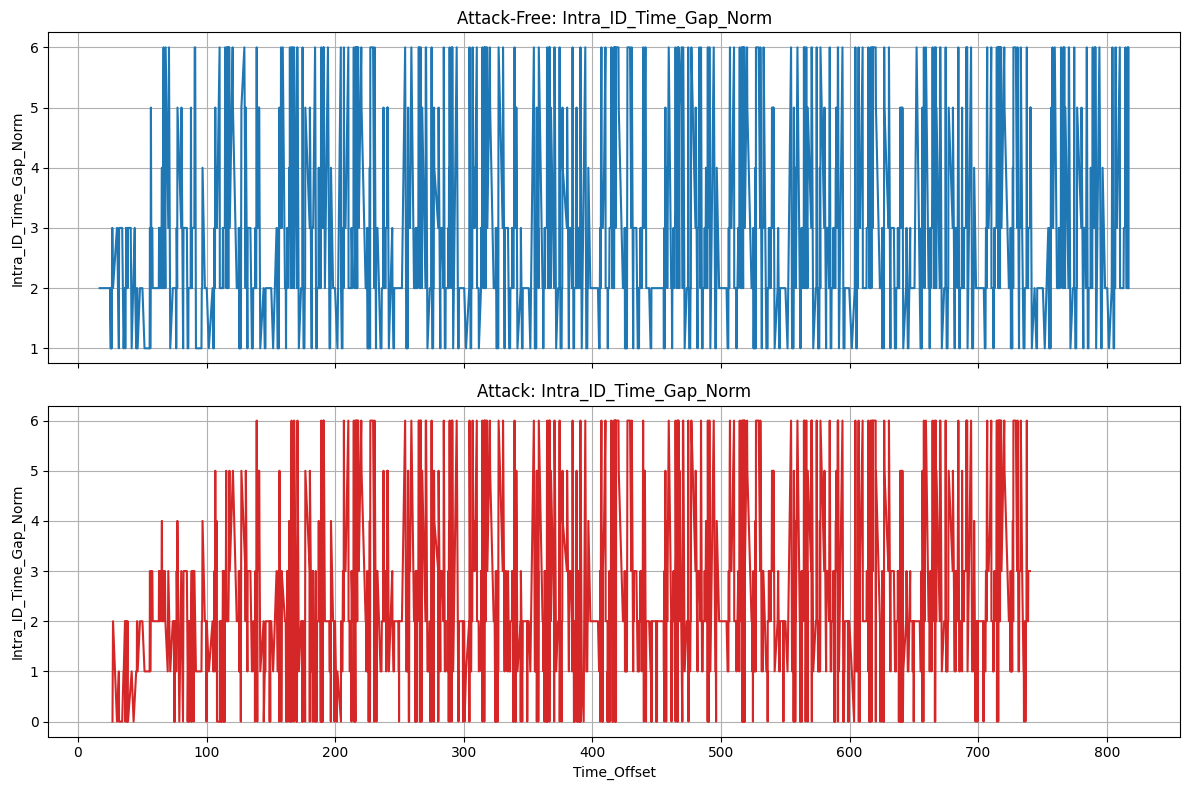

In [ ]:
NormalizePlotComparison(Sil_AF, Sil_Fuzz_R, 'Intra_ID_Time_Gap_Norm', 0, 2000)

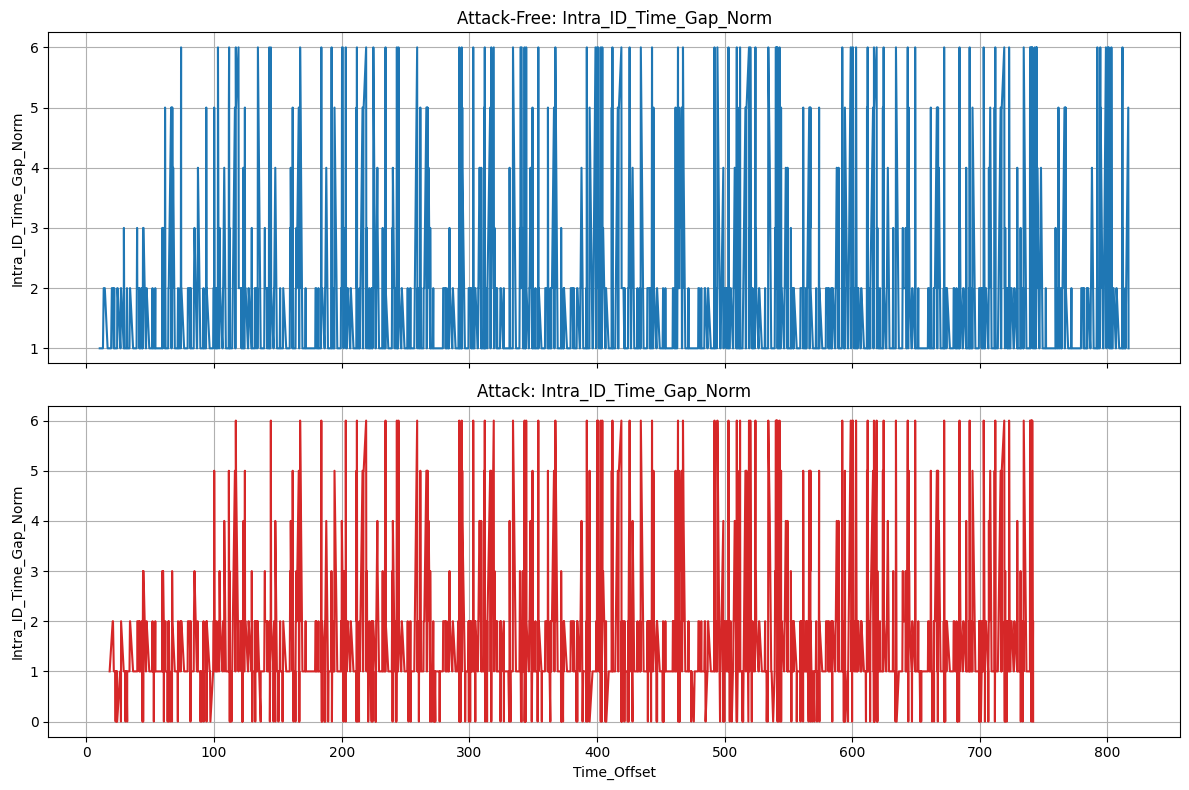

In [20]:
NormalizePlotComparison(Gen_AF, Gen_Fuzz_R, 'Intra_ID_Time_Gap_Norm', 0, 2000)

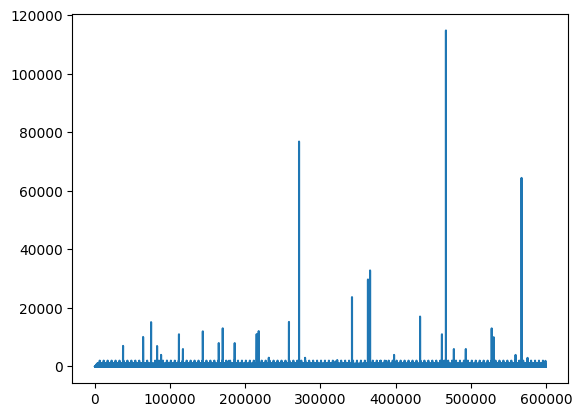

In [15]:
plt.plot(Gen_AF['Intra_ID_Time_Gap'])

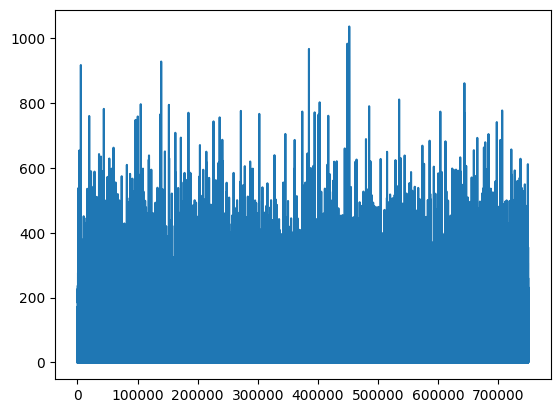

In [16]:
plt.plot(Kia_Fuzz_Test['Intra_ID_Time_Gap'])

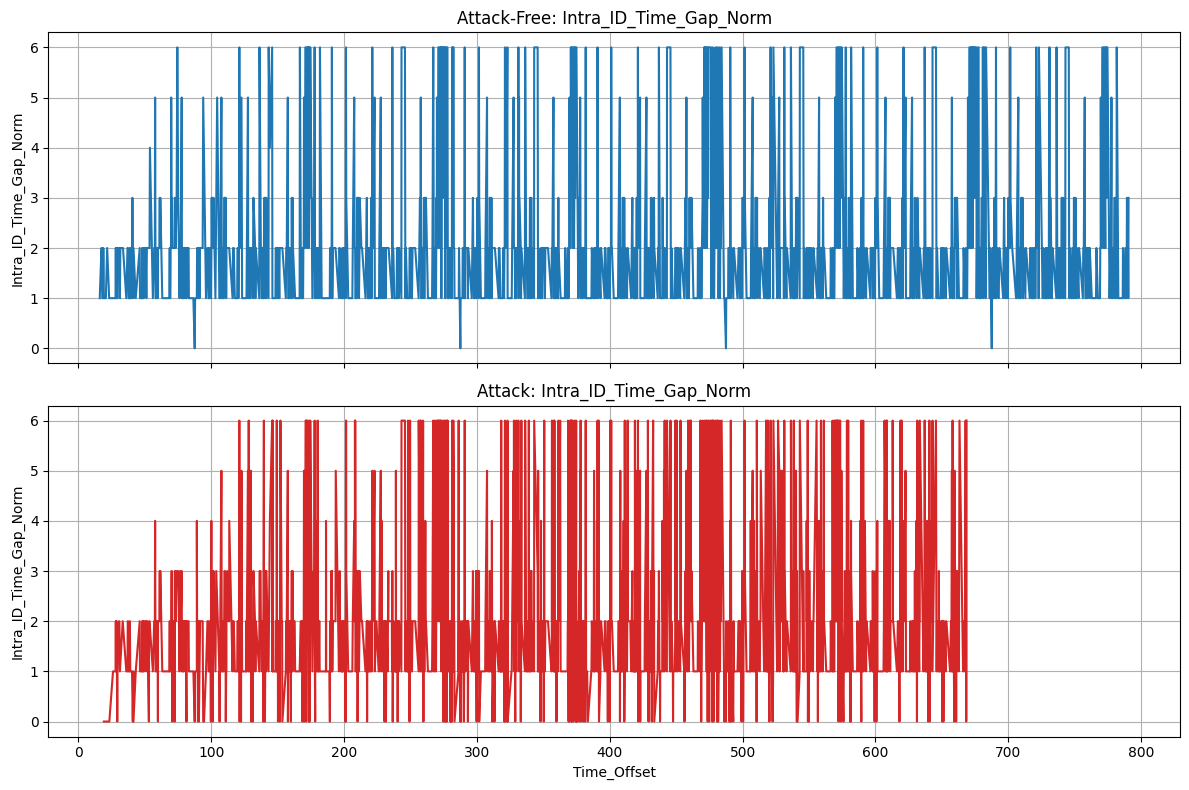

In [17]:
NormalizePlotComparison(Gen_AF, Kia_Fuzz_Test, 'Intra_ID_Time_Gap_Norm', 0, 2000)

In [1]:
import pandas as pd
import numpy as np
import os
from DataGenSrc.CANDataGenTimeFreq import CANDataInjection
from DataGenSrc.CANFDDataGenTimeFreq import CANFDDataInjection

In [2]:
path = "/home/lisa/Arupreza/UIDS-II/Input_data/"

Kia_AF = pd.read_csv(path + "Kia_AF.csv")
Tesla_AF = pd.read_csv(path + "Tesla_AF.csv")
Gen_AF = pd.read_csv(path + "Gen_AF.csv")
Sil_AF = pd.read_csv(path + "Sil_AF.csv")

/tmp/ipykernel_1350237/1286754281.py:5: DtypeWarning: Columns (22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  Gen_AF = pd.read_csv(path + "Gen_AF.csv")


In [ ]:
# DoS Attack Injection
Kia_DoS_L = CANDataInjection(
    type_of_attack="Fuzz",         # Specify the attack type as "DoS"
    orig_df=Kia_AF,        # The original DataFrame you are working with
    time_gap_range=(2, 3),       # Specify time gap range for attack injection
    label="Fuzz"                   # Attack label
)

Injecting 'Fuzz' messages:   0%|          | 0/228124 [00:00<?, ?it/s]


Done – injected 162990 Fuzz messages.


In [28]:
# DoS Attack Injection
Tesla_DoS_L = CANDataInjection(
    type_of_attack="Fuzz",         # Specify the attack type as "DoS"
    orig_df=Tesla_AF,        # The original DataFrame you are working with
    time_gap_range=(1, 1.35),       # Specify time gap range for attack injection
    label="Fuzz"                   # Attack label
)

Injecting 'Fuzz' messages:   0%|          | 0/191615 [00:00<?, ?it/s]


Done – injected 163004 Fuzz messages.


In [ ]:
# DoS Attack Injection
Sil_DoS_L = CANDataInjection(
    type_of_attack="Fuzz",         # Specify the attack type as "DoS"
    orig_df=Sil_AF,        # The original DataFrame you are working with
    time_gap_range=(3.5, 7),       # Specify time gap range for attack injection
    label="Fuzz"                   # Attack label
)

Injecting 'Fuzz' messages:   0%|          | 0/233389 [00:00<?, ?it/s]


Done – injected 166814 Fuzz messages.


In [ ]:
Gen_DoS_L = CANFDDataInjection(
    type_of_attack="Fuzz",
    orig_df=Gen_AF,
    time_gap_range=(3.5, 7),
    label="Fuzz"
)

Injecting 'Fuzz' messages:   0%|          | 0/238021 [00:00<?, ?it/s]


Done – injected 158715 Fuzz messages.


In [35]:
Kia_DoS_L.to_csv(os.path.join(path, 'Kia_Fuzz_H.csv'), index=False)
Tesla_DoS_L.to_csv(os.path.join(path, 'Tesla_Fuzz_H.csv'), index=False)
Sil_DoS_L.to_csv(os.path.join(path, 'Sil_Fuzz_H.csv'), index=False)
Gen_DoS_L.to_csv(os.path.join(path, 'Gen_Fuzz_H.csv'), index=False)

In [49]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from DataGenSrc.CANFuzz import InjectFuzzAattacks
from AnalysisSrc.assets import LoadPreprocessData, LoadAllDatasets, NormalizePlotComparison
from DataGenSrc.CANFDFuzz import CANFDDataInjectionCountFreq
from DataGenSrc.CANDataGenCountFreq import CANDataInjectionCountFreq
from DataGenSrc.CANFDDataGenCountFreq import CANFDDataInjectionCountFreq

In [11]:
path = "/home/lisa/Arupreza/UIDS-II/Normal_Dataset/"

Kia_AF = pd.read_csv(path + "Kia_AF.csv")
Tesla_AF = pd.read_csv(path + "Tesla_AF.csv")
Gen_AF = pd.read_csv(path + "Gen_AF.csv")
Sil_AF = pd.read_csv(path + "Sil_AF.csv")

/tmp/ipykernel_2648357/1896888317.py:5: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  Gen_AF = pd.read_csv(path + "Gen_AF.csv")


In [67]:
Kia_Rep_LL = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Kia_AF,
    injection_df=Kia_AF[:300000],  # This is required for Replay
    injection_frequency=(1, 33),  # 5 replay attacks per 30 messages
    label="Replay"
)

Sequential injection… 100% complete
Done – injected 18179 sequential messages in 18179 groups.


In [68]:
Tesla_Rep_LL = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Tesla_AF,
    injection_df=Tesla_AF[:300000],  # This is required for Replay
    injection_frequency=(1, 33),  # 5 replay attacks per 30 messages
    label="Replay"
)

Sequential injection… 100% complete
Done – injected 18179 sequential messages in 18179 groups.


In [69]:
Sil_Rep_LL = CANDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Sil_AF,
    injection_df=Sil_AF[:300000],  # This is required for Replay
    injection_frequency=(1, 33),  # 5 replay attacks per 30 messages
    label="Replay"
)

Sequential injection… 100% complete
Done – injected 18178 sequential messages in 18178 groups.


In [70]:
Gen_Rep_LL = CANFDDataInjectionCountFreq(
    type_of_attack="Replay",
    orig_df=Gen_AF,
    injection_df=Gen_AF[:300000],  # For replay, you need a source DataFrame
    injection_frequency=(1, 33)  # 6 Replay attacks per 30 messages
)

Injecting 'Replay' messages sequentially...
Generated 18180 'Replay' messages for injection.


In [71]:
Kia_Rep_LL.to_csv(os.path.join(path, 'Kia_Rep_LL.csv'), index=False)
Tesla_Rep_LL.to_csv(os.path.join(path, 'Tesla_Rep_LL.csv'), index=False)
Sil_Rep_LL.to_csv(os.path.join(path, 'Sil_Rep_LL.csv'), index=False)
Gen_Rep_LL.to_csv(os.path.join(path, 'Gen_Rep_LL.csv'), index=False)

In [72]:
Kia_AF = LoadPreprocessData(path + "Kia_AF.csv")
Tesla_AF = LoadPreprocessData(path + "Tesla_AF.csv")
Gen_AF = LoadPreprocessData(path + "Gen_AF.csv")
Sil_AF = LoadPreprocessData(path + "Sil_AF.csv")

Kia_Fuzz_LL = LoadPreprocessData(path + "Kia_Rep_LL.csv")
Tesla_Fuzz_LL = LoadPreprocessData(path + "Tesla_Rep_LL.csv")
Sil_Fuzz_LL = LoadPreprocessData(path + "Sil_Rep_LL.csv")
Gen_Fuzz_LL = LoadPreprocessData(path + "Gen_Rep_LL.csv")

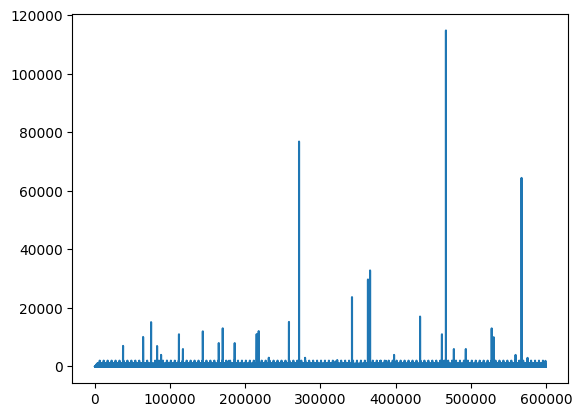

In [73]:
plt.plot(Kia_AF['Intra_ID_Time_Gap'])

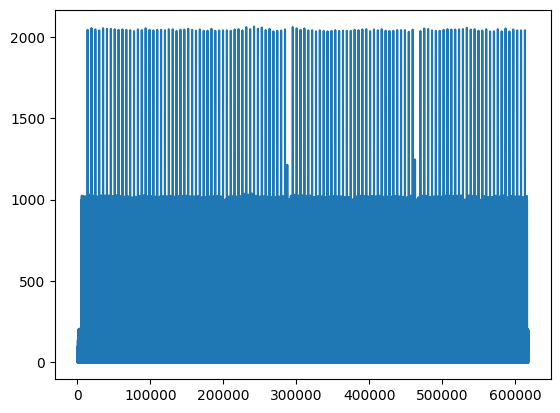

In [75]:
plt.plot(Gen_Fuzz_LL['Intra_ID_Time_Gap'])

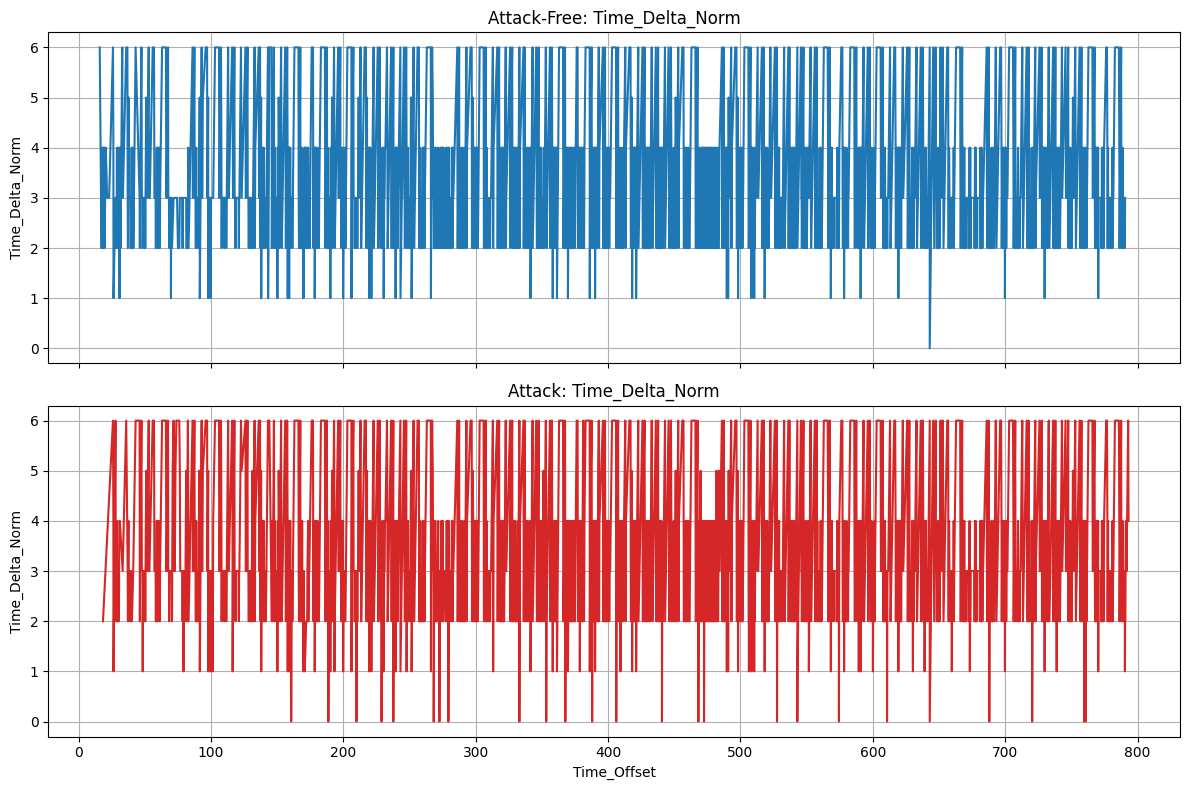

In [76]:
NormalizePlotComparison(Kia_AF, Kia_Fuzz_LL, 'Time_Delta_Norm', 0, 2000)

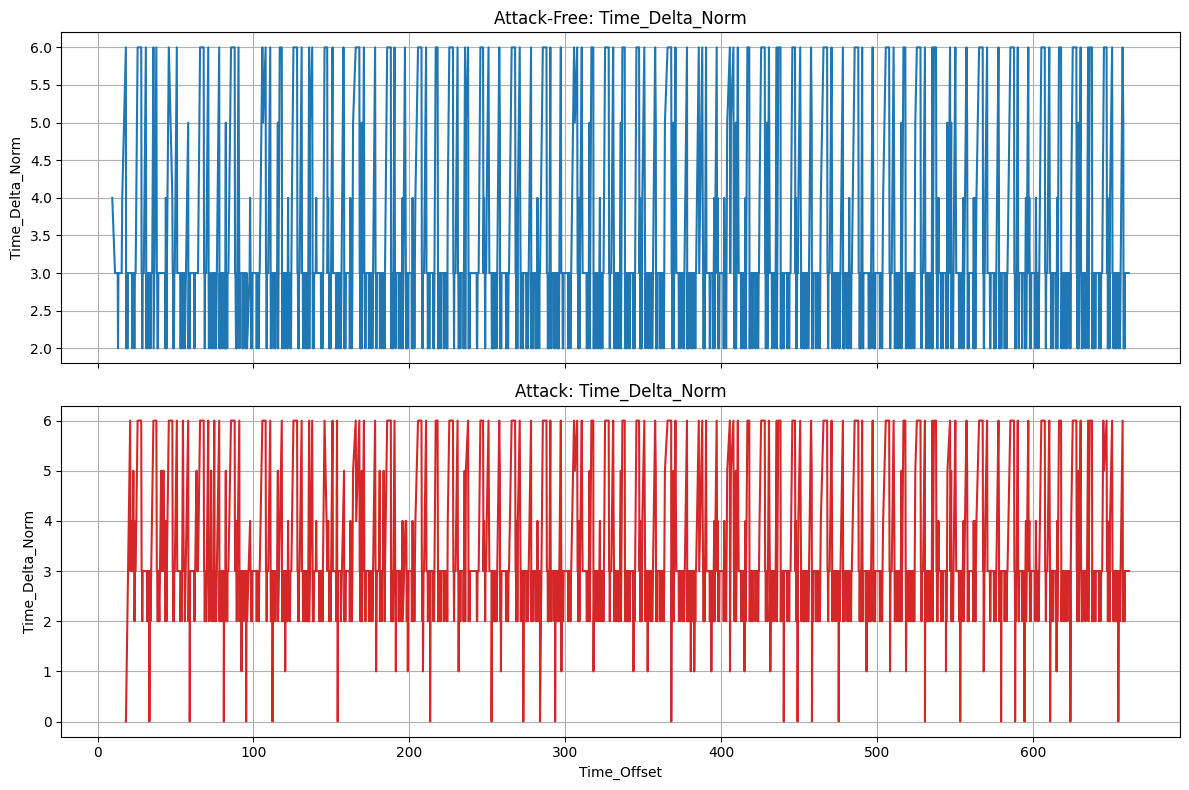

In [77]:
NormalizePlotComparison(Tesla_AF, Tesla_Fuzz_LL, 'Time_Delta_Norm', 0, 2000)

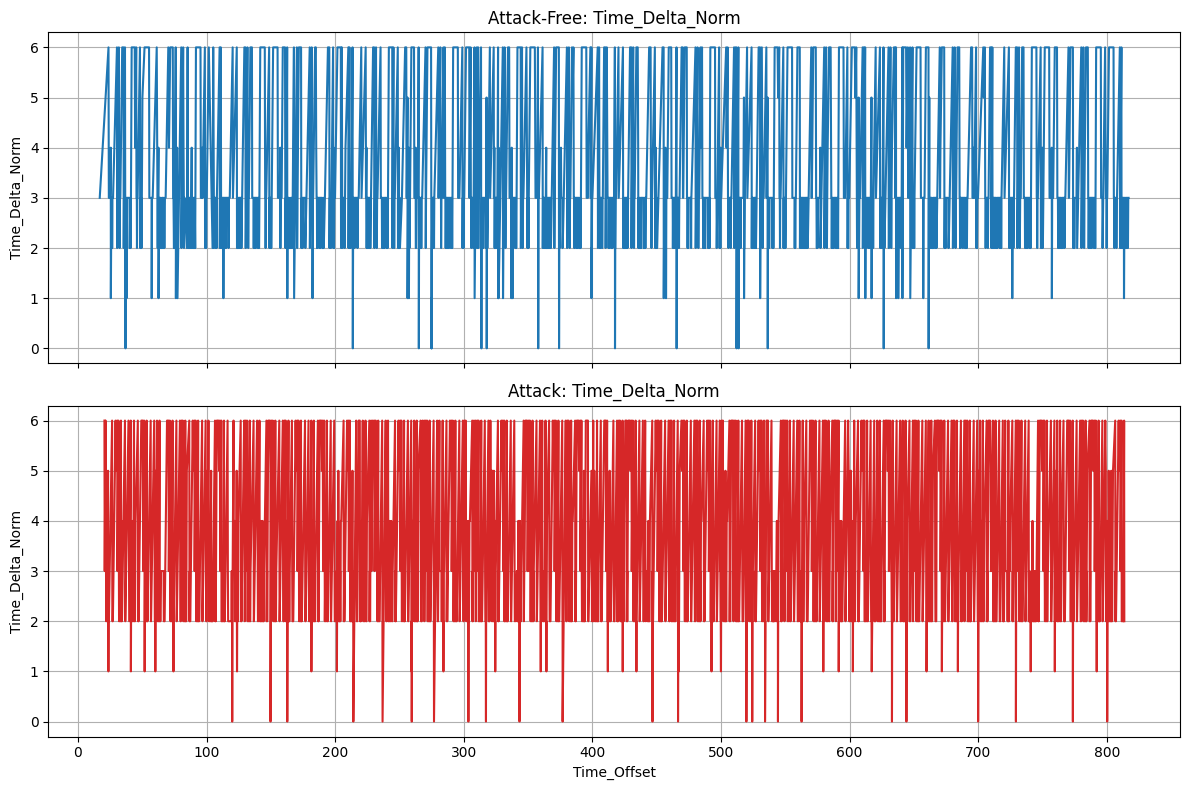

In [78]:
NormalizePlotComparison(Sil_AF, Gen_Fuzz_LL, 'Time_Delta_Norm', 0, 2000)

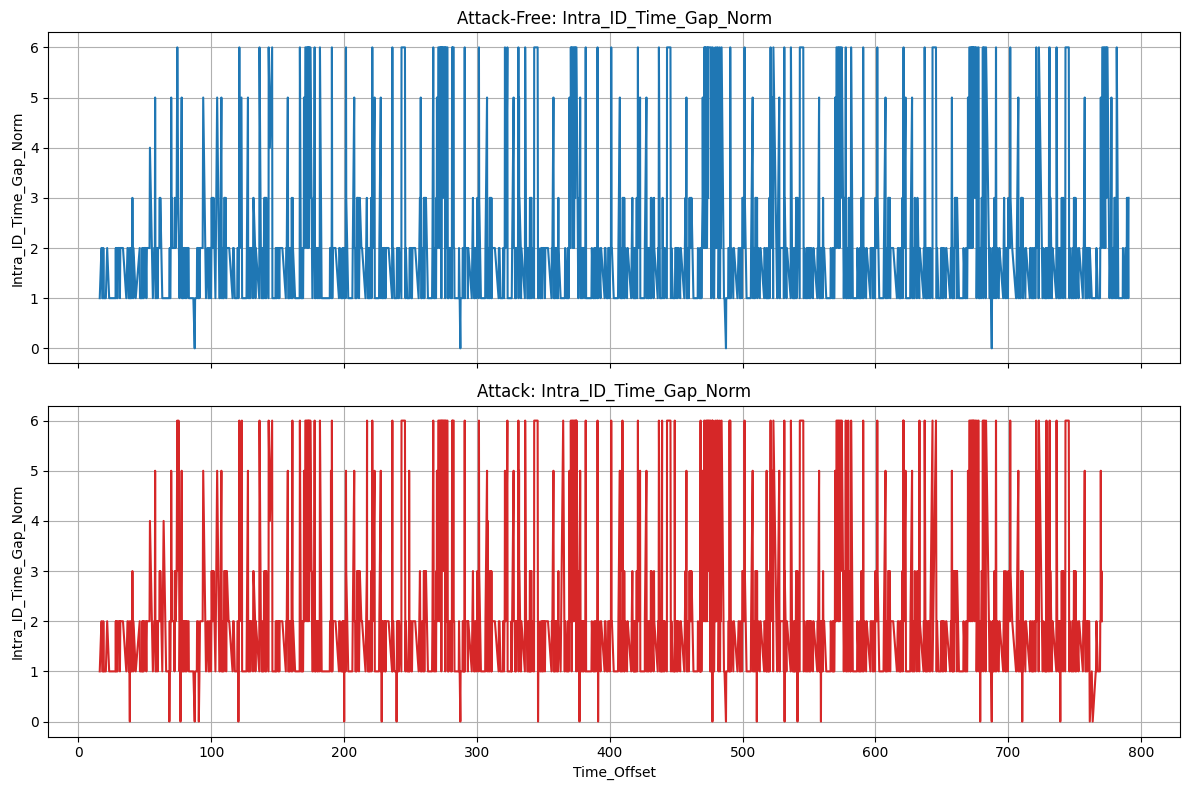

In [44]:
NormalizePlotComparison(Kia_AF, Kia_Fuzz_LL, 'Intra_ID_Time_Gap_Norm', 0, 2000)

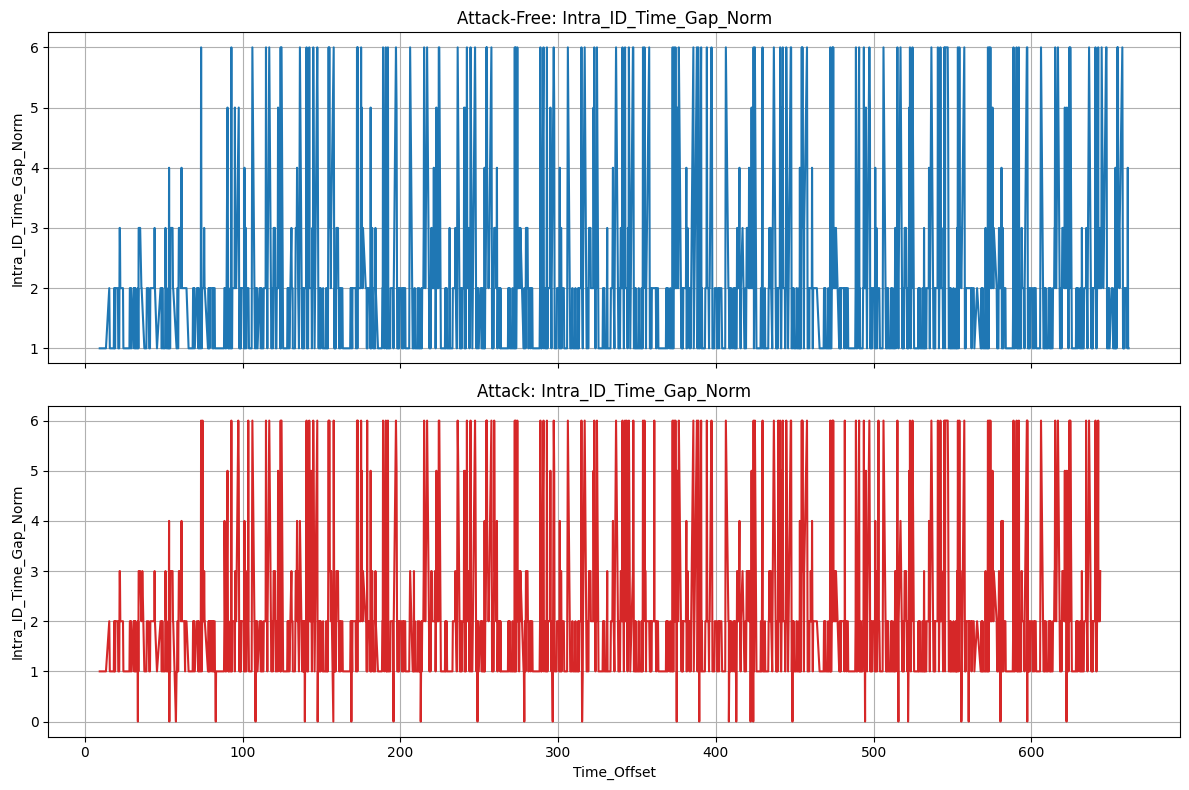

In [45]:
NormalizePlotComparison(Tesla_AF, Tesla_Fuzz_LL, 'Intra_ID_Time_Gap_Norm', 0, 2000)

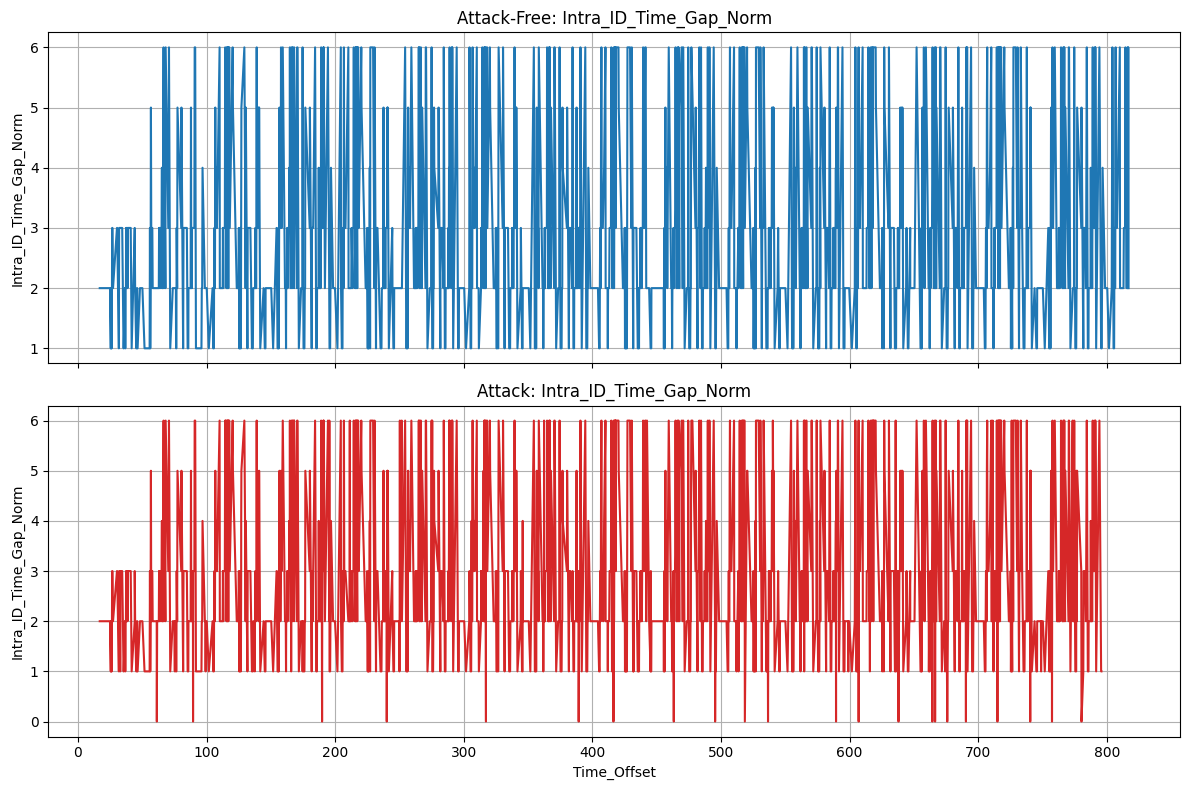

In [46]:
NormalizePlotComparison(Sil_AF, Sil_Fuzz_LL, 'Intra_ID_Time_Gap_Norm', 0, 2000)

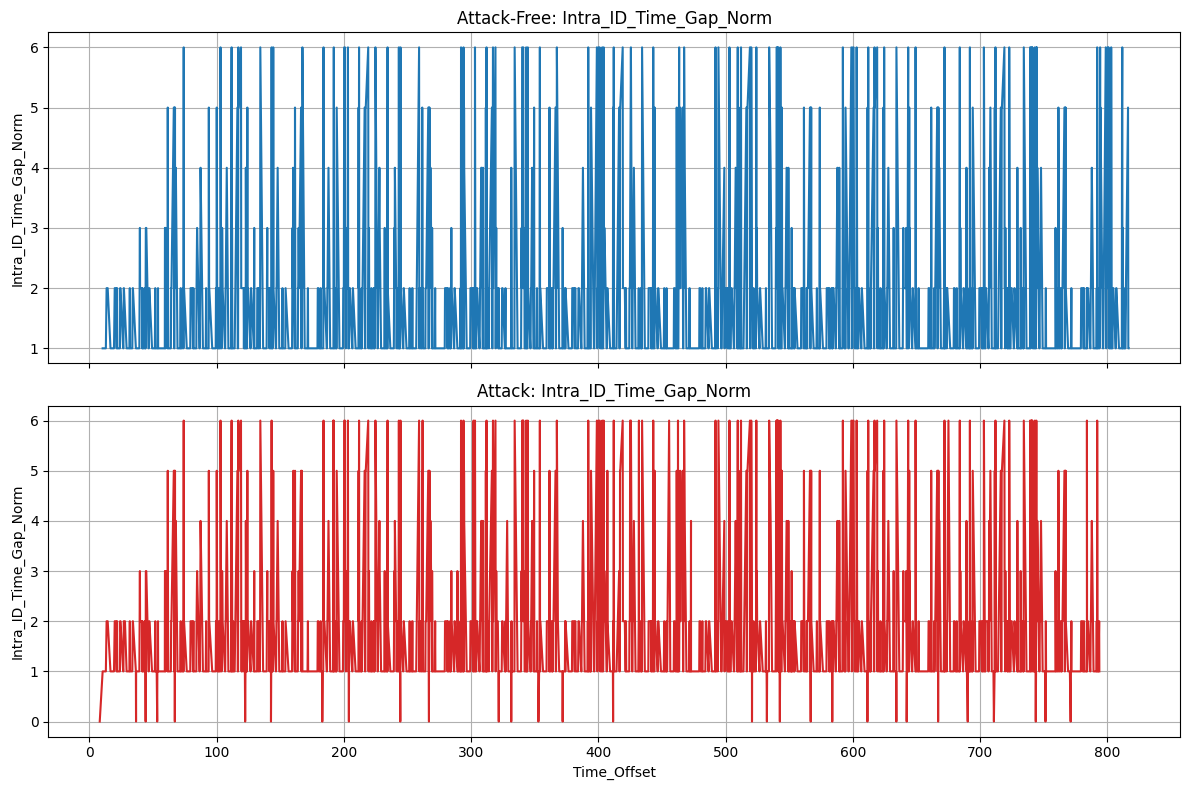

In [47]:
NormalizePlotComparison(Gen_AF, Gen_Fuzz_LL, 'Intra_ID_Time_Gap_Norm', 0, 2000)